# Camino Example Workflow

We're going to use `camino` to fit a single JWST defocused imaging dataset, initializing at zero OPD across the full pupil.

In [1]:
from pathlib import Path

from camino.fitting import FitConfig, load_data, fit_data
from camino.data_utils import download_wlp8_wlm8, next_wfs_epoch

First, download data from MAST; we're going to go with 18 December 2025, for no particular reason. `FIT_NPIX` sets the detector window: 128×128 pixels here, or 256×256 to include more of the PSF wings (about 3× slower per iteration).

In [2]:
OBS_DATE = "2025-12-18"
FIT_MODE = "pixel"
FIT_NPIX = 128  # detector window: 128 or 256

date_tag = OBS_DATE.replace("-", "")
mode_tag = FIT_MODE.replace("_", "")

OUTPUT_DIR = Path(f"{date_tag}_{mode_tag}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WLP8_IMAGE_PATH, WLM8_IMAGE_PATH = download_wlp8_wlm8(
    OBS_DATE,
    download_dir=OUTPUT_DIR / "data",
)

config = FitConfig.for_mode(
    FIT_MODE,
    fit_npix=FIT_NPIX,
    show_plots=True,
)

Date     : 2025-12-18
OPD      : O2025121801
Detector : NRCA1
WLM8     : jw07464177001_03104_00001 | 2025-12-17T08:00:43.4780000
WLP8     : jw07464177001_03105_00001 | 2025-12-17T08:05:01.1410000
Already exists: jw07464177001_03104_00001_nrca1_cal.fits
Already exists: jw07464177001_03105_00001_nrca1_cal.fits


Load the data into a format `camino` can work with.

In [3]:
data = load_data(
    WLP8_IMAGE_PATH,
    WLM8_IMAGE_PATH,
    config=config,
)

Initialize the OPD at zero and fit by stochastic gradient descent, progressively adding in more features until we have a decent initialization point for a fast BFGS fit.

CAMINO pixel: 128x128 cutouts; zero initial OPD


Stage 1 — SGD defocus and positions: 100%|██████████| 60/60 [00:09<00:00,  6.50it/s, loss=7.515393e+06]


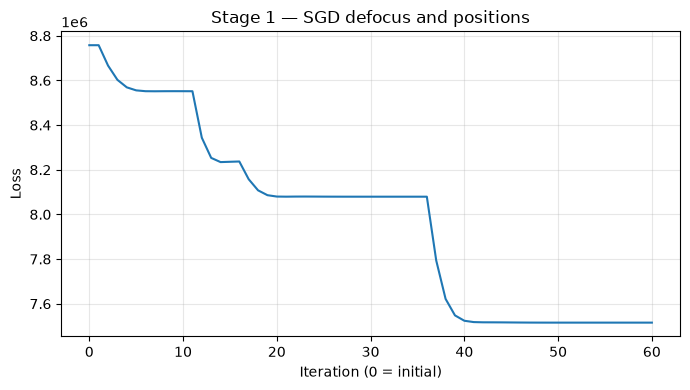

Stage 2 — L-BFGS-B: 100%|██████████| 75/75 [00:10<00:00,  6.98iter/s, grad=4.378e-03, loss=4.346650e+05]


Stage 2 — L-BFGS-B: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH; iterations=75, loss=4.34665027e+05


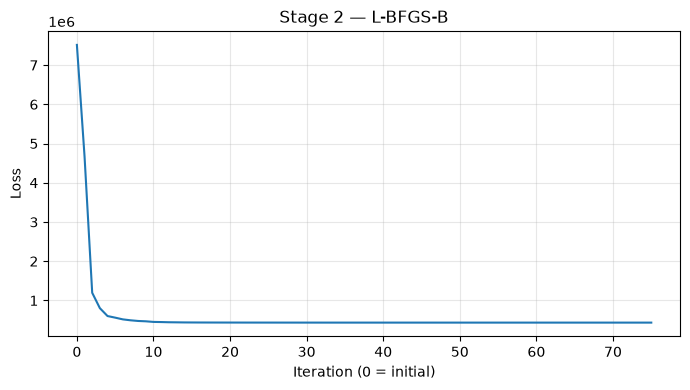

CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [4]:
# 3. Fit from zero; loss curves are displayed and results are saved.
result = fit_data(data=data, output_dir=OUTPUT_DIR)
print(result.scipy_result.message)


That converged pretty fast! It should converge even faster on a GPU. Let's check out a comparison to the MAST saved OPD maps - we should do a lot better:

iterating query, tdelta=3.0

MAST OPD query around UTC: 2025-12-18T12:00:00.000
                        MJD: 61027.5

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/O2025121801-NRCA1_FP6-1.fits
	Date (MJD):	 61026.3338
	Delta time:	 -1.1662 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2025122101-NRCA1_FP6-1.fits
	Date (MJD):	 61030.3798
	Delta time:	 2.8798 days
User requested choosing OPD time closest in time to 2025-12-18T12:00:00.000, which is O2025121801-NRCA1_FP6-1.fits, delta time -1.166 days
MAST WSS: O2025121801-NRCA1_FP6-1.fits
WLP8: CAMINO mean(z²)=13.543; MAST mean(z²)=65.806
WLM8: CAMINO mean(z²)=12.960; MAST mean(z²)=63.109


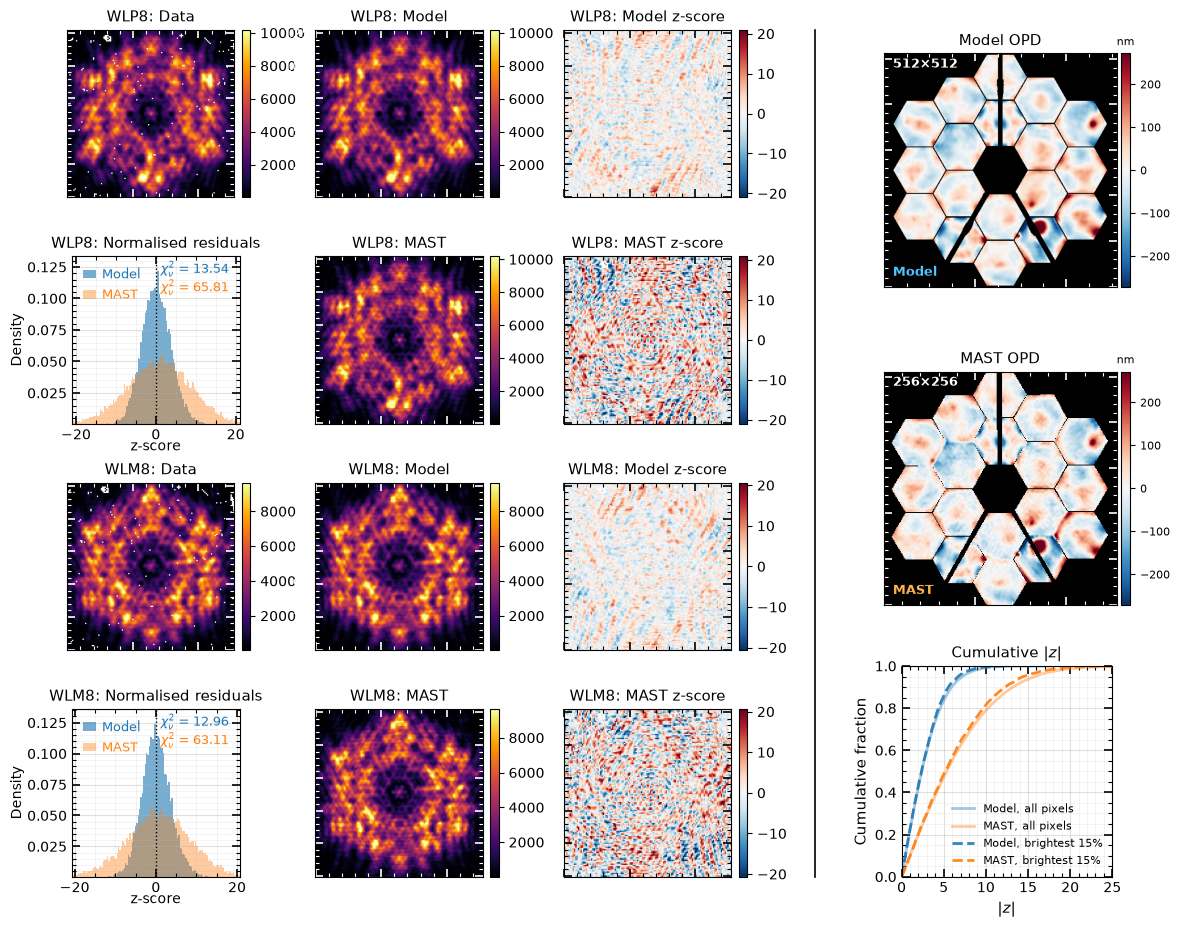

In [5]:
# 4. Compare with MAST; displays the figure and saves PNG/PDF in OUTPUT_DIR.
from camino.fitting import get_mast_wss_path

MAST_WSS_PATH = get_mast_wss_path(f"{OBS_DATE}T12:00:00", choice="closest")

print("MAST WSS:", MAST_WSS_PATH.name)


comparison = result.compare_with_mast(
    MAST_WSS_PATH, calc_hdu={"WLM8": 6, "WLP8": 11},
)


## Warm start on the next epoch

The telescope's wavefront changes slowly between wavefront-sensing epochs, so the OPD we just recovered should be an excellent starting point for the next one. `next_wfs_epoch` finds the next epoch that has a WLP8/WLM8 pair, and we download and load it just as before.

In [6]:
NEXT_EPOCH = next_wfs_epoch(OBS_DATE)
NEXT_DIR = Path(f"{NEXT_EPOCH:%Y%m%d}_{mode_tag}")

next_paths = download_wlp8_wlm8(NEXT_EPOCH, download_dir=NEXT_DIR / "data")
data_next = load_data(*next_paths, config=config)

Next epoch: 2025-12-21 09:06 UTC (O2025122101)
Date     : 2025-12-21
OPD      : O2025122101
Detector : NRCA1
WLM8     : jw07126115001_03104_00001 | 2025-12-21T09:06:51.1200000
WLP8     : jw07126115001_03105_00001 | 2025-12-21T09:10:58.0960000
Already exists: jw07126115001_03104_00001_nrca1_cal.fits
Already exists: jw07126115001_03105_00001_nrca1_cal.fits


Passing `initial=result` skips the SGD stage: it refits the pointing with a quick BFGS fit of the four position parameters, holding the OPD fixed, then runs only the L-BFGS-B stage from the previous epoch's OPD.

CAMINO pixel: 128x128 cutouts; warm start from previous fit


Warm start — BFGS position refit: 100%|██████████| 16/16 [00:02<00:00,  6.91iter/s, grad=7.968e-04, loss=3.209945e+05]

Warm start — BFGS position refit: Optimization terminated successfully.; iterations=16, loss=3.20994501e+05


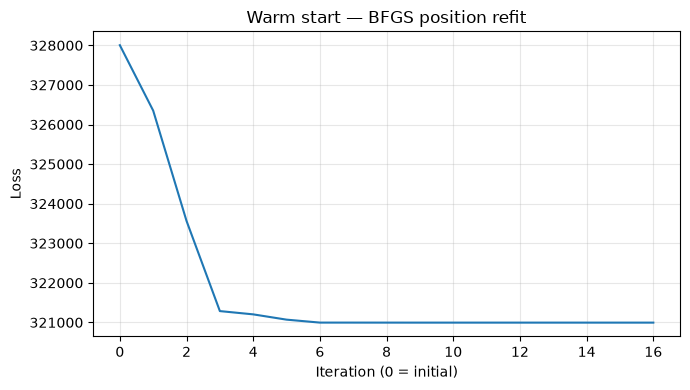

Stage 2 — L-BFGS-B: 100%|██████████| 52/52 [00:07<00:00,  7.37iter/s, grad=4.246e-03, loss=3.947688e+05]


Stage 2 — L-BFGS-B: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL; iterations=52, loss=3.94768770e+05


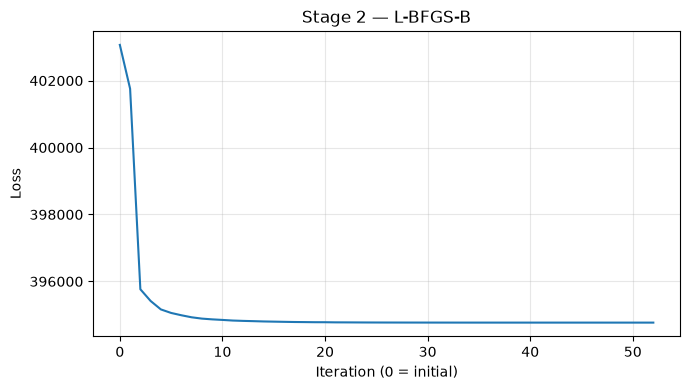

CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


In [7]:
result_next = fit_data(data=data_next, initial=result, output_dir=NEXT_DIR)
print(result_next.scipy_result.message)

For comparison, fit the same epoch from zero, quietly, and overlay the two L-BFGS-B loss curves relative to the best loss either run reaches.

CAMINO pixel: 128x128 cutouts; zero initial OPD
Stage 2 — L-BFGS-B: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH; iterations=78, loss=3.98379369e+05
from zero (after SGD) :  23.7 s in total, 78 L-BFGS-B iterations (never reaches 0.1% of best), final loss 3.983794e+05
warm start            :  11.7 s in total, 52 L-BFGS-B iterations (4 to reach 0.1% of best), final loss 3.947688e+05


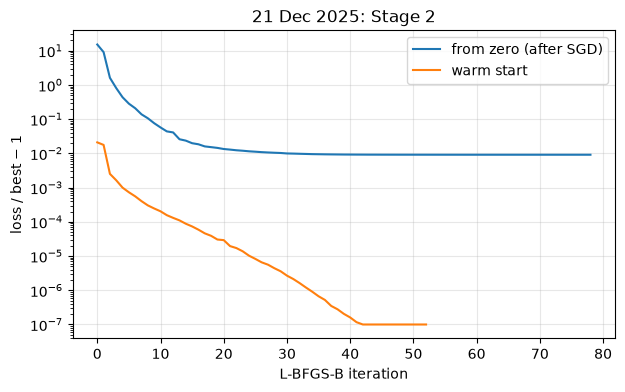

In [8]:
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

quiet = dataclasses.replace(config, show_plots=False, progress=False)
result_next_cold = fit_data(data=load_data(*next_paths, config=quiet))


def stage2_losses(r):
    h = next(h for h in r.histories if h.name.startswith("Stage 2"))
    return h, np.array([h.initial_loss, *h.losses])


best = min(result_next.scipy_result.fun, result_next_cold.scipy_result.fun)
fig, ax = plt.subplots(figsize=(7, 4))
for label, r in [("from zero (after SGD)", result_next_cold), ("warm start", result_next)]:
    h, losses = stage2_losses(r)
    excess = losses / best - 1
    close = np.flatnonzero(excess <= 1e-3)
    within = f"{close[0]} to reach" if close.size else "never reaches"
    print(
        f"{label:22s}: {r.runtime_seconds:5.1f} s in total, "
        f"{h.result.nit} L-BFGS-B iterations ({within} 0.1% of best), "
        f"final loss {h.result.fun:.6e}"
    )
    ax.semilogy(np.maximum(excess, 1e-7), label=label)
ax.set(xlabel="L-BFGS-B iteration", ylabel="loss / best − 1", title=f"{NEXT_EPOCH:%d %b %Y}: Stage 2")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

From the warm start, L-BFGS-B is within a fraction of a percent of the best loss after a handful of iterations; the rest only polish to the tight default tolerances. The fit from zero needs the SGD stage and many more iterations, and still ends at a slightly higher loss. Finally, compare the warm-started fit with MAST:


MAST OPD query around UTC: 2025-12-21T09:06:51.100
                        MJD: 61030.37975810185

The given datetime *exactly* matches the datetime of an OPD file:
URI -- mast:JWST/product/O2025122101-NRCA1_FP6-1.fits
Date (MJD) -- 61030.37975810185
User requested choosing OPD time closest in time to 2025-12-21T09:06:51.100, which is O2025122101-NRCA1_FP6-1.fits, delta time 0.000 days
MAST WSS: O2025122101-NRCA1_FP6-1.fits
WLP8: CAMINO mean(z²)=11.458; MAST mean(z²)=55.662
WLM8: CAMINO mean(z²)=10.899; MAST mean(z²)=51.876


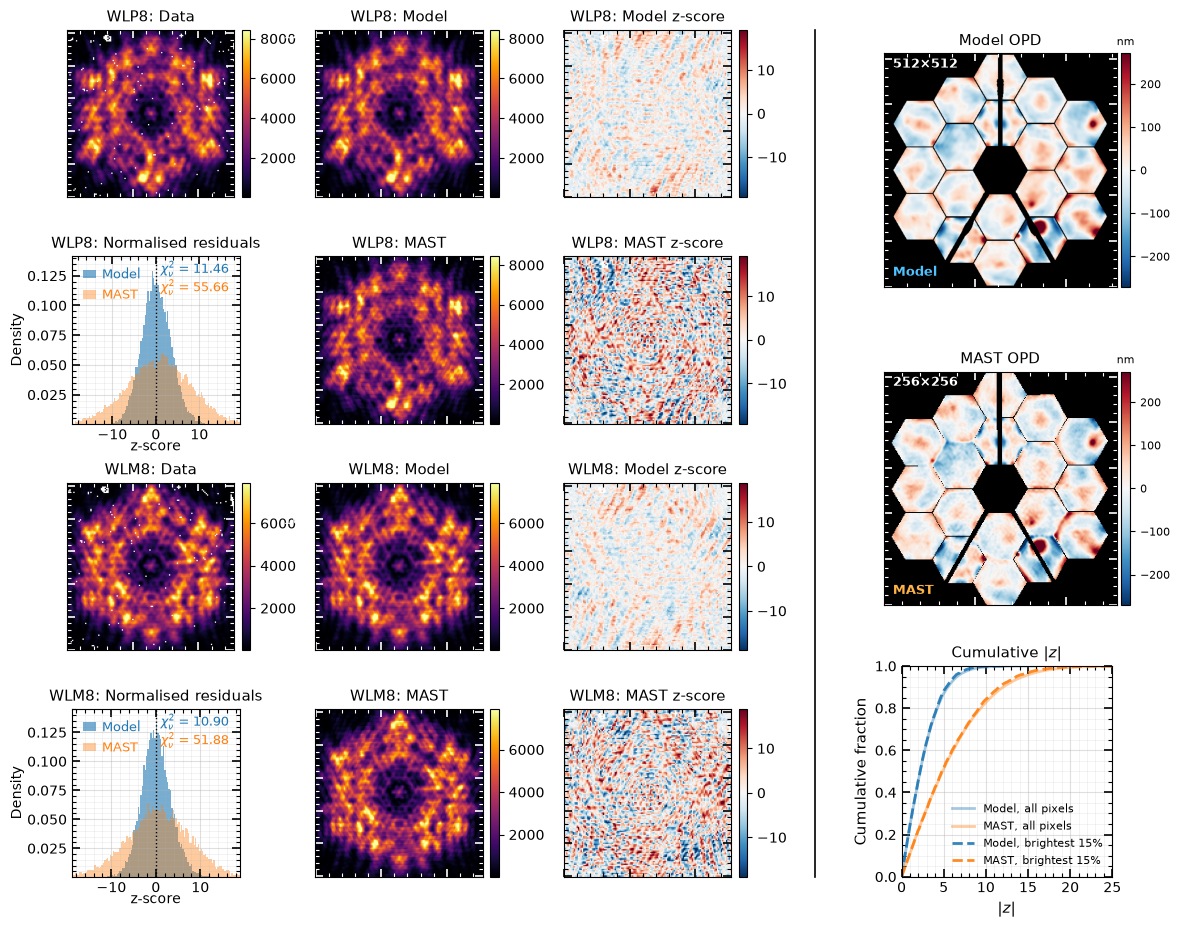

In [9]:
MAST_WSS_NEXT = get_mast_wss_path(NEXT_EPOCH.isoformat(), choice="closest")

print("MAST WSS:", MAST_WSS_NEXT.name)

comparison_next = result_next.compare_with_mast(
    MAST_WSS_NEXT, calc_hdu={"WLM8": 6, "WLP8": 11},
)